In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
import pandas as pd
path = '/content/drive/MyDrive/The_Cancer_data_1500_V2 (1).csv'

In [ ]:
sns.set_theme(style="whitegrid")

In [ ]:
df = pd.read_csv(path)

In [ ]:
# Show the first 5 rows of the dataset
df.head()

,Age,Gender,BMI,Smoking,GeneticRisk,PhysicalActivity,AlcoholIntake,CancerHistory,Diagnosis
0,58,1,16.085313,0,1,8.146251,4.148219,1,1
1,71,0,30.828784,0,1,9.361630,3.519683,0,0
2,48,1,38.785084,0,2,5.135179,4.728368,0,1
3,34,0,30.040296,0,0,9.502792,2.044636,0,0
4,62,1,35.479721,0,0,5.356890,3.309849,0,1


In [ ]:
# Show the number of rows and columns
df.shape

(1500, 9)

In [ ]:
# Show the names of all columns
df.columns

Index(['Age', 'Gender', 'BMI', 'Smoking', 'GeneticRisk', 'PhysicalActivity',
       'AlcoholIntake', 'CancerHistory', 'Diagnosis'],
      dtype='object')

In [ ]:
# Give us information about columns, data types and missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Age               1500 non-null   int64  
 1   Gender            1500 non-null   int64  
 2   BMI               1500 non-null   float64
 3   Smoking           1500 non-null   int64  
 4   GeneticRisk       1500 non-null   int64  
 5   PhysicalActivity  1500 non-null   float64
 6   AlcoholIntake     1500 non-null   float64
 7   CancerHistory     1500 non-null   int64  
 8   Diagnosis         1500 non-null   int64  
dtypes: float64(3), int64(6)
memory usage: 105.6 KB


In [ ]:
# Count how many missing values are present in each column
df.isnull().sum()

,0
Age,0
Gender,0
BMI,0
Smoking,0
GeneticRisk,0
PhysicalActivity,0
AlcoholIntake,0
CancerHistory,0
Diagnosis,0


In [ ]:
# Count completely duplicated rows
df.duplicated().sum()

np.int64(0)

In [ ]:
# Give us statistical information about numerical columns
df.describe()

,Age,Gender,BMI,Smoking,GeneticRisk,PhysicalActivity,AlcoholIntake,CancerHistory,Diagnosis
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,50.320000,0.490667,27.513321,0.269333,0.508667,4.897929,2.417987,0.144000,0.371333
std,17.640968,0.500080,7.230012,0.443761,0.678895,2.866162,1.419318,0.351207,0.483322
min,20.000000,0.000000,15.000291,0.000000,0.000000,0.002410,0.001215,0.000000,0.000000
25%,35.000000,0.000000,21.483134,0.000000,0.000000,2.434609,1.210598,0.000000,0.000000
50%,51.000000,0.000000,27.598494,0.000000,0.000000,4.834316,2.382971,0.000000,0.000000
75%,66.000000,1.000000,33.850837,1.000000,1.000000,7.409896,3.585624,0.000000,1.000000
max,80.000000,1.000000,39.958688,1.000000,2.000000,9.994607,4.987115,1.000000,1.000000


In [ ]:
# Check the different values present in each categorical/binary column

print("Gender:", df["Gender"].unique())
print("Smoking:", df["Smoking"].unique())
print("GeneticRisk:", df["GeneticRisk"].unique())
print("CancerHistory:", df["CancerHistory"].unique())
print("Diagnosis:", df["Diagnosis"].unique())

Gender: [1 0]
Smoking: [0 1]
GeneticRisk: [1 2 0]
CancerHistory: [1 0]
Diagnosis: [1 0]


In [ ]:
# Count how many records belong to each diagnosis class
df["Diagnosis"].value_counts()

,count
Diagnosis,
0,943
1,557


In [ ]:
# Convert diagnosis counts into percentages
df["Diagnosis"].value_counts(normalize=True) * 100

,proportion
Diagnosis,
0,62.866667
1,37.133333


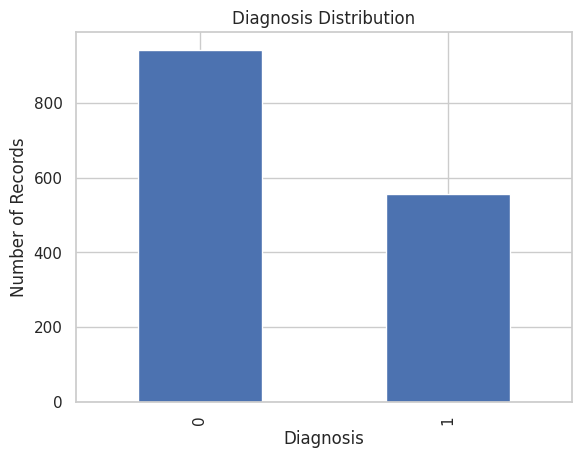

In [ ]:
# Count the number of records in each diagnosis class
df["Diagnosis"].value_counts().plot(kind="bar")

# Give the graph a title
plt.title("Diagnosis Distribution")

# Label the x-axis
plt.xlabel("Diagnosis")

# Label the y-axis
plt.ylabel("Number of Records")

# Show the graph
plt.show()

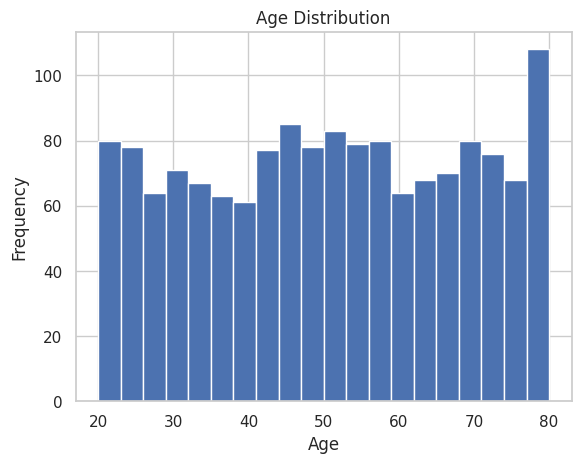

In [ ]:
# Create a histogram of Age
df["Age"].plot(kind="hist", bins=20)

# Add a title
plt.title("Age Distribution")

# Label the x-axis
plt.xlabel("Age")

# Label the y-axis
plt.ylabel("Frequency")

# Display the graph
plt.show()

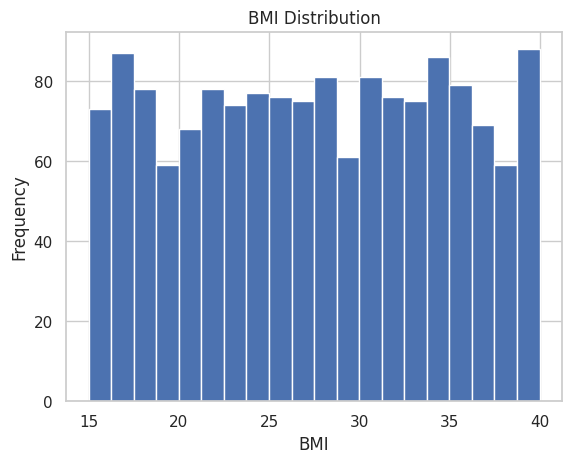

In [ ]:
# Show the distribution of BMI values
df["BMI"].plot(kind="hist", bins=20)

# Add title
plt.title("BMI Distribution")

# Label axes
plt.xlabel("BMI")
plt.ylabel("Frequency")

# Show graph
plt.show()

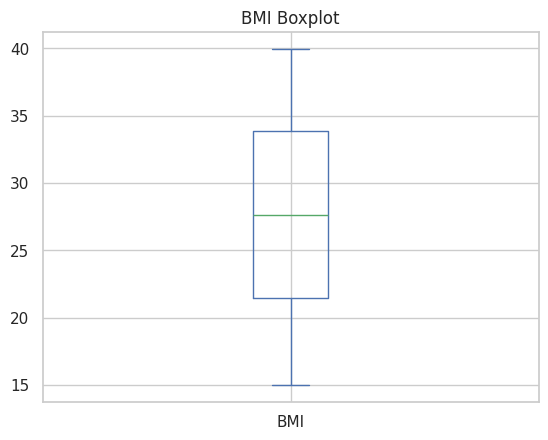

In [ ]:
# Create a boxplot for BMI
df["BMI"].plot(kind="box")

# Add title
plt.title("BMI Boxplot")

# Show the graph
plt.show()

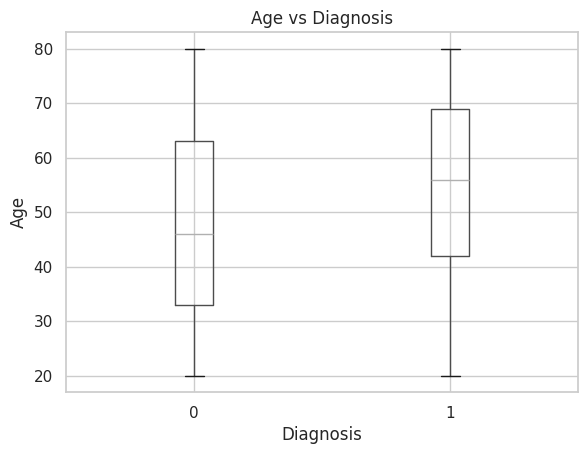

In [ ]:
# Compare Age distributions for the two diagnosis groups
df.boxplot(column="Age", by="Diagnosis")

# Add title
plt.title("Age vs Diagnosis")

# Remove the automatic extra title
plt.suptitle("")

# Label axes
plt.xlabel("Diagnosis")
plt.ylabel("Age")

# Show graph
plt.show()

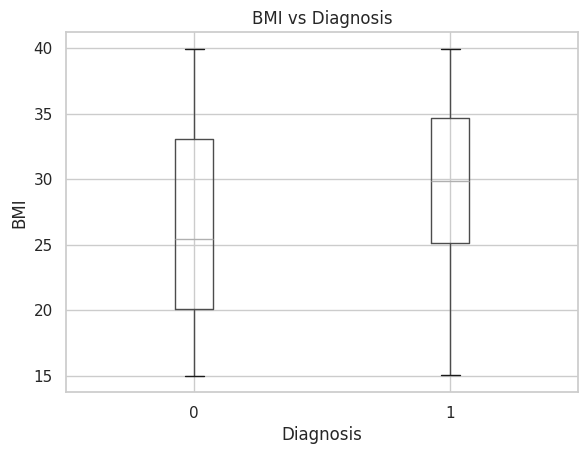

In [ ]:
# Compare BMI between the two diagnosis groups
df.boxplot(column="BMI", by="Diagnosis")

# Add title
plt.title("BMI vs Diagnosis")

# Remove automatic title
plt.suptitle("")

# Label axes
plt.xlabel("Diagnosis")
plt.ylabel("BMI")

# Show graph
plt.show()

In [ ]:
# Count Smoking values for each Diagnosis group
pd.crosstab(df["Smoking"], df["Diagnosis"])

Diagnosis,0,1
Smoking,,
0,762,334
1,181,223


In [ ]:
# Calculate percentages within each Smoking category
pd.crosstab(
    df["Smoking"],
    df["Diagnosis"],
    normalize="index"
) * 100

Diagnosis,0,1
Smoking,,
0,69.525547,30.474453
1,44.801980,55.198020


In [ ]:
# Count Diagnosis values for each CancerHistory group
pd.crosstab(df["CancerHistory"], df["Diagnosis"])

Diagnosis,0,1
CancerHistory,,
0,907,377
1,36,180


In [ ]:
# Convert the counts into percentages
pd.crosstab(
    df["CancerHistory"],
    df["Diagnosis"],
    normalize="index"
) * 100

Diagnosis,0,1
CancerHistory,,
0,70.638629,29.361371
1,16.666667,83.333333


In [ ]:
# Calculate correlations between all columns
df.corr()

,Age,Gender,BMI,Smoking,GeneticRisk,PhysicalActivity,AlcoholIntake,CancerHistory,Diagnosis
Age,1.000000,0.007145,0.030246,-0.013914,-0.027025,0.016396,0.003209,-0.010996,0.196603
Gender,0.007145,1.000000,-0.012516,0.035384,-0.004674,0.023401,0.009723,0.007657,0.250336
BMI,0.030246,-0.012516,1.000000,-0.012616,0.011392,0.011480,0.004711,-0.010824,0.187560
Smoking,-0.013914,0.035384,-0.012616,1.000000,-0.021039,-0.043817,-0.001660,0.016368,0.226999
GeneticRisk,-0.027025,-0.004674,0.011392,-0.021039,1.000000,-0.039721,-0.016864,-0.010833,0.253472
PhysicalActivity,0.016396,0.023401,0.011480,-0.043817,-0.039721,1.000000,0.033856,0.018136,-0.150089
AlcoholIntake,0.003209,0.009723,0.004711,-0.001660,-0.016864,0.033856,1.000000,0.055403,0.212772
CancerHistory,-0.010996,0.007657,-0.010824,0.016368,-0.010833,0.018136,0.055403,1.000000,0.392188
Diagnosis,0.196603,0.250336,0.187560,0.226999,0.253472,-0.150089,0.212772,0.392188,1.000000


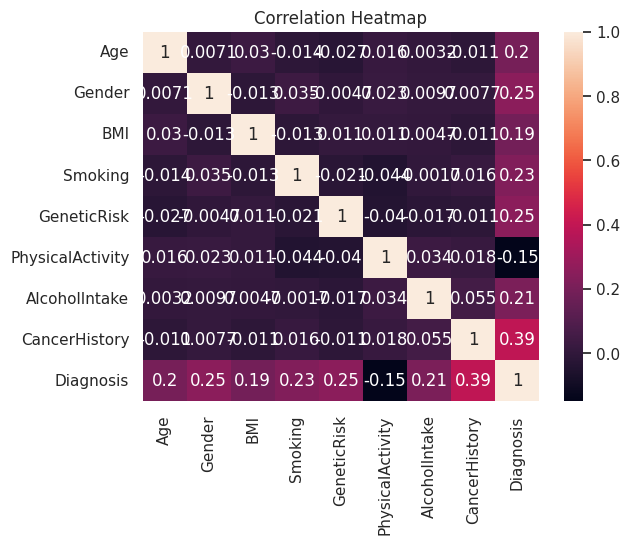

In [ ]:
# Import seaborn for a nicer statistical visualization
import seaborn as sns

# Calculate the correlation matrix
correlation = df.corr()

# Create a heatmap
sns.heatmap(correlation, annot=True)

# Add a title
plt.title("Correlation Heatmap")

# Show the graph
plt.show()

In [ ]:
# Show how strongly each numerical column is correlated with Diagnosis
df.corr()["Diagnosis"].sort_values(ascending=False)

,Diagnosis
Diagnosis,1.000000
CancerHistory,0.392188
GeneticRisk,0.253472
Gender,0.250336
Smoking,0.226999
AlcoholIntake,0.212772
Age,0.196603
BMI,0.187560
PhysicalActivity,-0.150089
